Loading & Prepping YOUR CSV...


<ipython-input-5-d3f3497ea082>:32: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['PM_lag1'] = df['PM 2.5 Mass'].shift(1).fillna(method='bfill')


Clean shape: (17431, 12)
Train/Test shapes: (13944, 11) (3487, 11)

🏆 RESULTS:
Basic Linear (raw):   R² = 0.038
Full Linear (enhanced): R² = 0.967
Ridge:                R² = 0.967
Lasso:                R² = 0.967


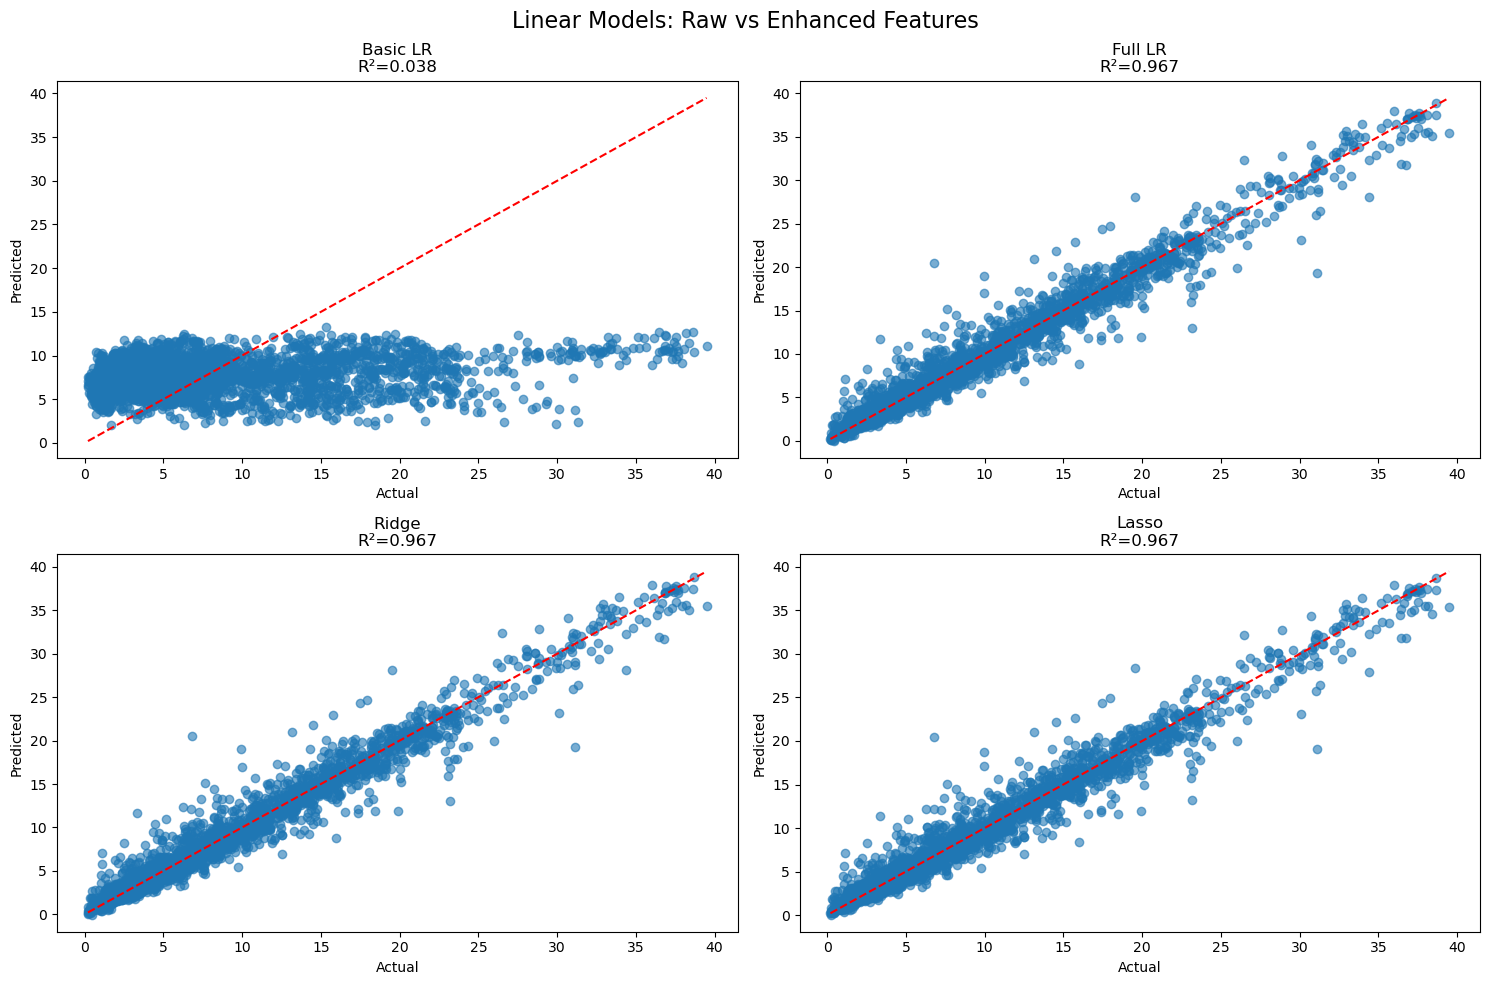

Linear Models Performance
Model                | RMSE     | MAE      | R²    
--------------------------------------------------


In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === COMPLETE STANDALONE PIPELINE ===
print("Loading & Prepping YOUR CSV...")

# Load your CSV
df = pd.read_csv('Weather data.csv')

# Safe column handling
cols_to_drop = ["Station Name", "Wind Dir. 10 m Syno. (∞)"]
existing_cols = [col for col in cols_to_drop if col in df.columns]
df = df.drop(existing_cols, axis=1, errors='ignore')

# Target first
df = df.dropna(subset=["PM 2.5 Mass"])

# Date features
df["Date (Local Standard Time)"] = pd.to_datetime(df["Date (Local Standard Time)"], errors="coerce")
df["hour"] = df["Date (Local Standard Time)"].dt.hour.fillna(12)
df["day"] = df["Date (Local Standard Time)"].dt.day.fillna(1)  
df["month"] = df["Date (Local Standard Time)"].dt.month.fillna(1)
df = df.drop("Date (Local Standard Time)", axis=1, errors='ignore')

# Enhanced features
df['wind_speed_sq'] = df['Wind Speed 10 m Syno. (km/h)'].fillna(df['Wind Speed 10 m Syno. (km/h)'].median()) ** 2
df['temp_dew_diff'] = df['Air Temp. Inst. (∞C)'].fillna(df['Air Temp. Inst. (∞C)'].median()) - df['Est. Dew Point Temp. (∞C)'].fillna(df['Est. Dew Point Temp. (∞C)'].median())
df['PM_lag1'] = df['PM 2.5 Mass'].shift(1).fillna(method='bfill')
df['PM_roll3'] = df['PM 2.5 Mass'].rolling(3, min_periods=1).mean()

df = df.dropna()
print(f"Clean shape: {df.shape}")

# Safe split (no index issues)
split_idx = int(0.8 * len(df))
X = df.drop("PM 2.5 Mass", axis=1)
y = df["PM 2.5 Mass"]
X_train = X.iloc[:split_idx].reset_index(drop=True)
X_test = X.iloc[split_idx:].reset_index(drop=True)
y_train = y.iloc[:split_idx].reset_index(drop=True)
y_test = y.iloc[split_idx:].reset_index(drop=True)

print("Train/Test shapes:", X_train.shape, X_test.shape)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Basic Raw (safe cols)
raw_cols = ['Air Temp. Inst. (∞C)', 'Est. Dew Point Temp. (∞C)', 'Humidity Inst. (%)', 'Wind Speed 10 m Syno. (km/h)']
raw_cols = [c for c in raw_cols if c in X.columns]
scaler_raw = StandardScaler()
X_train_raw = scaler_raw.fit_transform(X_train[raw_cols])
X_test_raw = scaler_raw.transform(X_test[raw_cols])

# Models
lr_basic = LinearRegression().fit(X_train_raw, y_train)
y_pred_basic = lr_basic.predict(X_test_raw)

lr_full = LinearRegression().fit(X_train_scaled, y_train)
y_pred_full = lr_full.predict(X_test_scaled)

ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

lasso = Lasso(alpha=0.01).fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Results
r2_basic = r2_score(y_test, y_pred_basic)
r2_full = r2_score(y_test, y_pred_full)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"\n🏆 RESULTS:")
print(f"Basic Linear (raw):   R² = {r2_basic:.3f}")
print(f"Full Linear (enhanced): R² = {r2_full:.3f}")
print(f"Ridge:                R² = {r2_ridge:.3f}")
print(f"Lasso:                R² = {r2_lasso:.3f}")

# Plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
predictions = {
    'Basic LR': y_pred_basic,
    'Full LR': y_pred_full,
    'Ridge': y_pred_ridge,
    'Lasso': y_pred_lasso
}
for i, (name, y_pred) in enumerate(predictions.items()):
    row, col = i//2, i%2
    axes[row,col].scatter(y_test, y_pred, alpha=0.6)
    axes[row,col].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[row,col].set_title(f'{name}\nR²={r2_score(y_test, y_pred):.3f}')
    axes[row,col].set_xlabel('Actual'); axes[row,col].set_ylabel('Predicted')
plt.suptitle('Linear Models: Raw vs Enhanced Features', fontsize=16)
plt.tight_layout()
plt.savefig('linear_comparison_fixed.png', dpi=150)
plt.show()

print("Linear Models Performance")
print("=" * 50)
print(f"{'Model':20} | {'RMSE':8} | {'MAE':8} | {'R²':6}")
print("-" * 50)


Loading CSV...
Cleaning data...


<ipython-input-6-ceafa1d502bd>:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill").fillna(method="ffill")


Clean shape: (17457, 12)
Train/Test shapes: (13965, 11) (3492, 11)
Training models...

Linear Models Performance
Model                   R2         RMSE          MAE
-----------------------------------------------------------------
Basic LR             0.026        6.986        5.314
Full LR              0.964        1.334        0.819
Ridge                0.964        1.334        0.819
Lasso                0.964        1.337        0.819

Results table:
      Model        R2      RMSE       MAE
0  Basic LR  0.025807  6.985994  5.314470
1   Full LR  0.964477  1.334016  0.819079
2     Ridge  0.964478  1.333996  0.819005
3     Lasso  0.964316  1.337042  0.819273


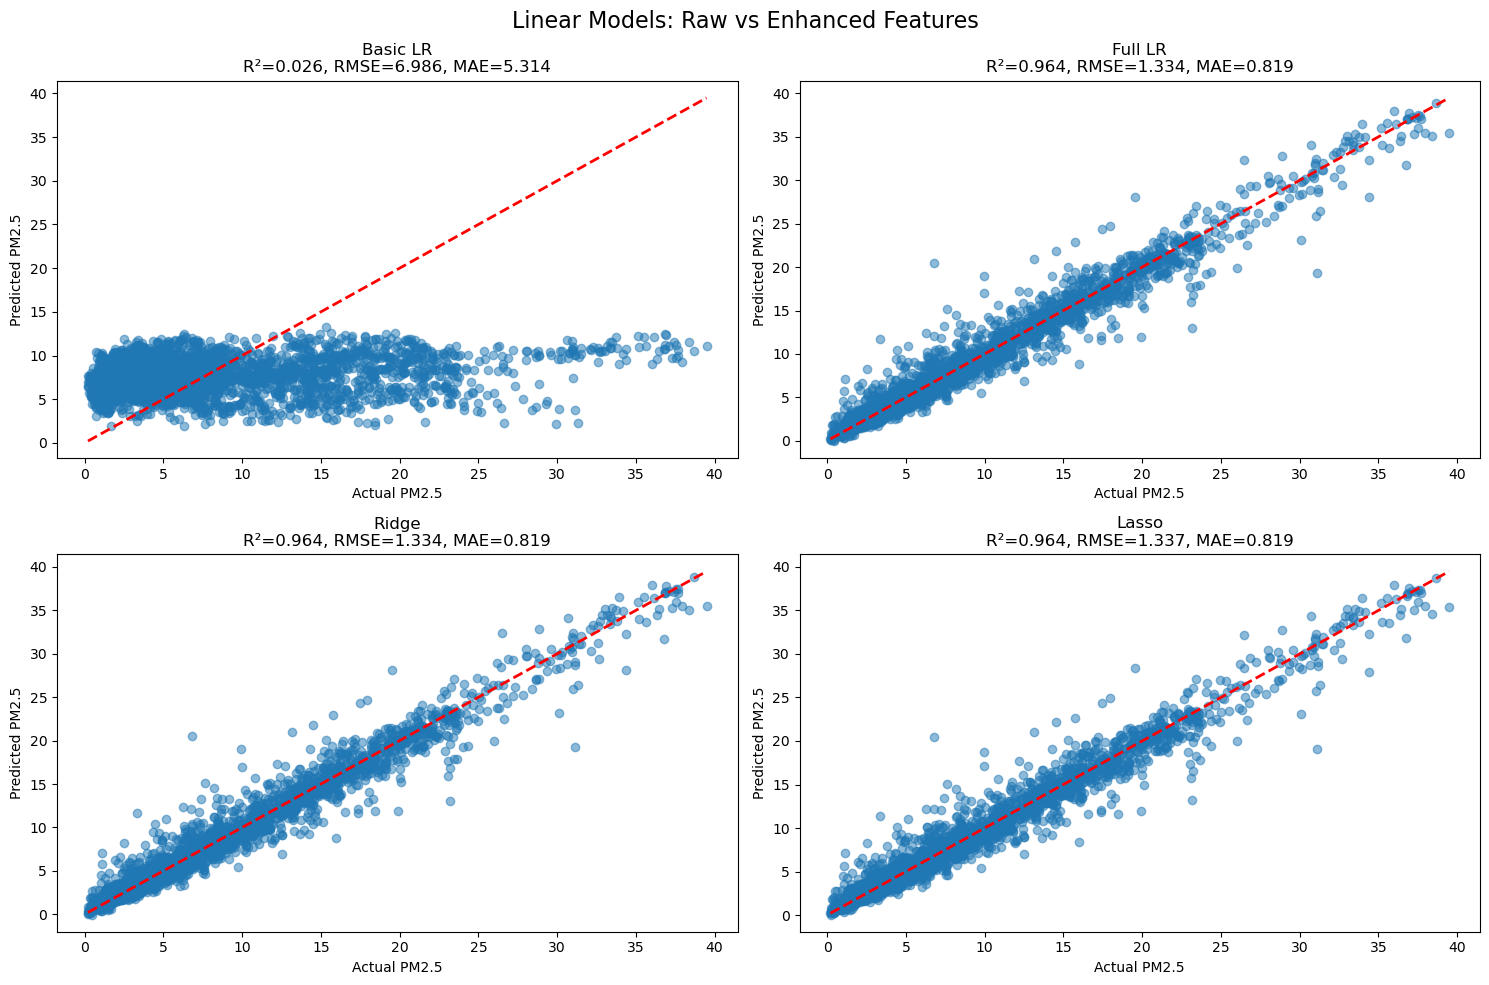

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. LOAD DATA
# =========================
print("Loading CSV...")
df = pd.read_csv("Weather data.csv")

# =========================
# 2. BASIC CLEANING
# =========================
print("Cleaning data...")

# Drop target NaNs first
df = df.dropna(subset=["PM 2.5 Mass"])

# Drop text/non-useful columns if they exist
cols_to_drop = ["Station Name", "Wind Dir. 10 m Syno. (∞)"]
existing_cols = [col for col in cols_to_drop if col in df.columns]
df = df.drop(existing_cols, axis=1, errors="ignore")

# Convert date column
df["Date (Local Standard Time)"] = pd.to_datetime(
    df["Date (Local Standard Time)"], errors="coerce"
)

# Create date features
df["hour"] = df["Date (Local Standard Time)"].dt.hour
df["day"] = df["Date (Local Standard Time)"].dt.day
df["month"] = df["Date (Local Standard Time)"].dt.month

# Fill time feature NaNs
df["hour"] = df["hour"].fillna(12)
df["day"] = df["day"].fillna(1)
df["month"] = df["month"].fillna(1)

# Drop original date column
df = df.drop("Date (Local Standard Time)", axis=1, errors="ignore")

# Enhanced engineered features
df["wind_speed_sq"] = (
    df["Wind Speed 10 m Syno. (km/h)"]
    .fillna(df["Wind Speed 10 m Syno. (km/h)"].median()) ** 2
)

df["temp_dew_diff"] = (
    df["Air Temp. Inst. (∞C)"].fillna(df["Air Temp. Inst. (∞C)"].median())
    - df["Est. Dew Point Temp. (∞C)"].fillna(df["Est. Dew Point Temp. (∞C)"].median())
)

df["PM_lag1"] = df["PM 2.5 Mass"].shift(1)
df["PM_roll3"] = df["PM 2.5 Mass"].rolling(3, min_periods=1).mean()

# Final cleanup
df = df.fillna(method="bfill").fillna(method="ffill")
df = df.dropna()

print("Clean shape:", df.shape)

# =========================
# 3. TRAIN / TEST SPLIT
# =========================
target_col = "PM 2.5 Mass"

X = df.drop(target_col, axis=1)
y = df[target_col]

split_idx = int(0.8 * len(df))

X_train = X.iloc[:split_idx].reset_index(drop=True)
X_test = X.iloc[split_idx:].reset_index(drop=True)
y_train = y.iloc[:split_idx].reset_index(drop=True)
y_test = y.iloc[split_idx:].reset_index(drop=True)

print("Train/Test shapes:", X_train.shape, X_test.shape)

# =========================
# 4. BASIC RAW FEATURES
# =========================
raw_cols = [
    "Air Temp. Inst. (∞C)",
    "Est. Dew Point Temp. (∞C)",
    "Humidity Inst. (%)",
    "Wind Speed 10 m Syno. (km/h)"
]
raw_cols = [c for c in raw_cols if c in X.columns]

scaler_raw = StandardScaler()
X_train_raw = scaler_raw.fit_transform(X_train[raw_cols])
X_test_raw = scaler_raw.transform(X_test[raw_cols])

# =========================
# 5. FULL ENHANCED FEATURES
# =========================
scaler_full = StandardScaler()
X_train_full = scaler_full.fit_transform(X_train)
X_test_full = scaler_full.transform(X_test)

# =========================
# 6. TRAIN MODELS
# =========================
print("Training models...")

lr_basic = LinearRegression()
lr_basic.fit(X_train_raw, y_train)
y_pred_basic = lr_basic.predict(X_test_raw)

lr_full = LinearRegression()
lr_full.fit(X_train_full, y_train)
y_pred_full = lr_full.predict(X_test_full)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_full, y_train)
y_pred_ridge = ridge.predict(X_test_full)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_full, y_train)
y_pred_lasso = lasso.predict(X_test_full)

# =========================
# 7. METRICS
# =========================
predictions = {
    "Basic LR": y_pred_basic,
    "Full LR": y_pred_full,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso
}

print("\nLinear Models Performance")
print("=" * 65)
print(f"{'Model':15} {'R2':>10} {'RMSE':>12} {'MAE':>12}")
print("-" * 65)

results = []

for name, y_pred in predictions.items():
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append([name, r2, rmse, mae])
    print(f"{name:15} {r2:10.3f} {rmse:12.3f} {mae:12.3f}")

# Optional results table
results_df = pd.DataFrame(results, columns=["Model", "R2", "RMSE", "MAE"])
print("\nResults table:")
print(results_df)

# =========================
# 8. PLOT
# =========================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--',
        linewidth=2
    )
    axes[i].set_title(f"{name}\nR²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")
    axes[i].set_xlabel("Actual PM2.5")
    axes[i].set_ylabel("Predicted PM2.5")

plt.suptitle("Linear Models: Raw vs Enhanced Features", fontsize=16)
plt.tight_layout()
plt.show()
